## The performance of a lock complex
In this notebook, we simulate a lock object on a network. Randomly generated, evenly sized vessels sampled from an exponential distribution have to pass this lock. We add a complex lock object to the graph. Vessels are levelled in the same lock operation if they can fit inside the lock, and register with the lock operator before the start of the lock operation. Based on this behaviour, we will quantify the performance of the lock in terms of efficiency and capacity.

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt

# import of basic core mixins and utils for creating objects, inspecting the output and plotting
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.utils import create_object, generate_vessels_from_distribution
from opentnsim.core.visualizations import generate_vessel_gantt_chart

# import of mixin to include hydrodynamic data in the simulation
from opentnsim.environment.mixins.hydrodynamics import HydrodynamicData

# import of utils for graph visualization
from opentnsim.graph.visualizations import plot_graph

# import of modules important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable
from opentnsim.lock.calculations import estimate_lock_capacity, calculate_lock_occupancy
from opentnsim.lock.logutils import calculate_cycle_information, get_vessel_delays

# package(s) needed for inspecting the output
import numpy as np
import pandas as pd

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.3.2a2.dev3+g514a752b4.d20260603


#### 0. Create environment

In [2]:
# start simpy environment
simulation_start = datetime.datetime(2026, 5, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2026, 5, 7, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.simulation_start = simulation_start
env.simulation_stop = simulation_stop
env.epoch = simulation_start

#### 1. Create graph
We create a directional graph with a layout similar to that of notebooks 0201, 0202, and 0203. However, we add two additional edges prior to nodes 0 and 1 to show that a lock can also be implemented in a larger graph. These edges are 20km long.

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.DiGraph()

# add nodes
graph.add_node('-1',geometry=transform(wgs84eqd_to_wgs84rad,Point(-25000,0)))
graph.add_node('0',geometry=transform(wgs84eqd_to_wgs84rad,Point(-5000,0)))
graph.add_node('1',geometry=transform(wgs84eqd_to_wgs84rad,Point(5000,0)))
graph.add_node('+1',geometry=transform(wgs84eqd_to_wgs84rad,Point(25000,0)))

# add edges
graph.add_edge('-1','0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-25000, 0),Point(-5000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('0','-1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(-25000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('0','1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(5000, 0)])), weight=1, length_m=10000)
graph.add_edge('1','0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(-5000, 0)])), weight=1, length_m=10000)
graph.add_edge('1','+1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(25000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('+1','1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(25000, 0),Point(5000, 0)])), weight=1, length_m=25000-5000)

# add graph to environment
env.graph = graph

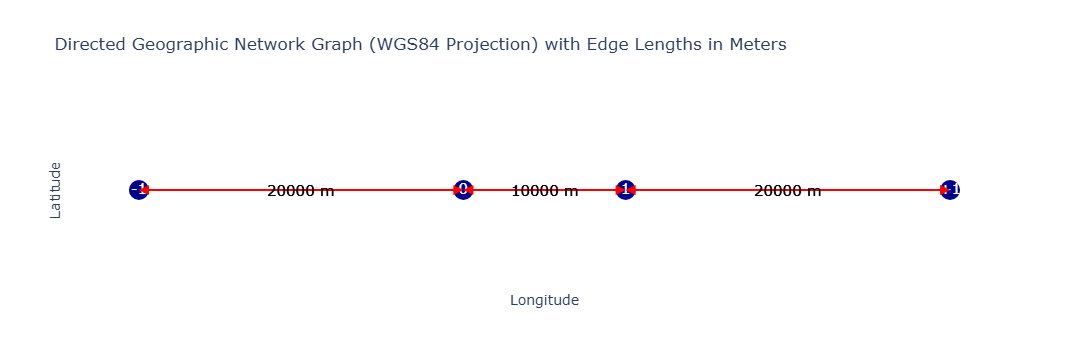

In [4]:
plot_graph(graph)

#### 1+ Adding environmental data

In [5]:
hydrodynamic_data = xr.open_dataset(Path.cwd() / 'data/Locking/hydrodynamic_data_IJmuiden.nc')

In [6]:
HydrodynamicData(env=env, hydrodynamic_data = hydrodynamic_data);

#### 1+ Adding infrastructure
We construct the same lock complex as before.

In [7]:
lock_chamber = IsLockChamber(env=env,
                             lock_depth = 10,
                             name='Lock',
                             gate_open = '1',
                             edge = ('0','1'),
                             geometry_m = Polygon([Point(-200, -25),Point(-200, 25),Point(200, 25),Point(200, -25)]),
                             time_step = 10.,
                             closing_gate_in_between_operations = True)

In [8]:
# The minimum required input for a lock complex are waiting areas at both sides of the lock
waiting_area_A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area A',
                                   edge = ('0','1'),
                                   orientation = 0,
                                   distance_from_edge_start = 0)

waiting_area_B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area B',
                                   edge = ('1','0'),
                                   orientation = 1,
                                   distance_from_edge_start = 0)

In [9]:
lock_complex = IsLockComplex(lock_chambers = [lock_chamber],
                             waiting_areas = [waiting_area_A, waiting_area_B],
                             registration_nodes = ['-1','+1'],
                             env=env,
                             name = 'Lock complex',)

#### 2. Create agents
We create the same vessel agent object.

In [10]:
# make your preferred Vessel class out of available mix-ins.
Vessel = create_object(
    "Vessel", 
    (
        LockComplexTraversable,     # allows to interact with a lock
    ), 
)

In [11]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

To better illustrate the lock's performance, we add two vessel generators at the network boundaries. From each direction, 10 equally sized vessels are generated randomly from an exponential distribution with a mean arrival rate of 30 minutes. We use different seeds to get different arrival times.

In [12]:
upstream_vessels = generate_vessels_from_distribution(env=env,
                                                      VesselClass = Vessel,
                                                      vessel_parameters = {'v':4, 'L':100, 'B':20, 'T':5, 'type':'tanker'},
                                                      mean_arrival_rate=60.,
                                                      number_of_vessels=10,
                                                      start_node = '-1',
                                                      end_node = '+1',
                                                      seed = 123)

downstream_vessels = generate_vessels_from_distribution(env=env,
                                                        VesselClass = Vessel,
                                                        vessel_parameters = {'v':4, 'L':100, 'B':20, 'T':5, 'type':'tanker'},
                                                        mean_arrival_rate=60.,
                                                        number_of_vessels=10,
                                                        start_node = '+1',
                                                        end_node = '-1',
                                                        seed = 456)

vessels = upstream_vessels + downstream_vessels

for vessel in vessels:
    env.process(mission(env, vessel))

#### 3. Run simulation
We run the simulation.

In [13]:
env.run()

,node_from,node_to,direction,lock_chamber,operation_index,vessels,capacity_L,capacity_B,time_potential_lock_gate_opening_stop,time_lock_operation_start,...,time_gate_opening_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
0,1,0,1,Lock,1,[<opentnsim.core.utils.Vessel object at 0x0000...,300.0,50.0,2026-05-01 02:09:48.708828,2026-05-01 02:11:16.208828,...,2026-05-01 02:59:58.881614470,2026-05-01 02:59:58.881614470,2026-05-01 03:00:47.477726822,2026-05-01 03:02:19.977726822,2026-05-01 03:02:47.477726822,0.564833,-0.426933,NaN,NaN,NaN


hiii Vessel 10


,node_from,node_to,direction,lock_chamber,operation_index,vessels,capacity_L,capacity_B,time_potential_lock_gate_opening_stop,time_lock_operation_start,...,time_gate_opening_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
1,0,1,0,Lock,0,[],400.0,50.0,2026-05-01 00:29:28.708828,2026-05-01 00:29:28.708828,...,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,-0.931067,-0.458533,NaN,NaN,NaN
0,1,0,1,Lock,1,[<opentnsim.core.utils.Vessel object at 0x0000...,300.0,50.0,2026-05-01 02:09:48.708828,2026-05-01 02:11:16.208828,...,2026-05-01 02:59:58.881614470,2026-05-01 02:59:58.881614470,2026-05-01 03:00:47.477726822,2026-05-01 03:02:19.977726822,2026-05-01 03:02:47.477726822,0.564833,-0.426933,NaN,NaN,NaN
2,0,1,0,Lock,2,[<opentnsim.core.utils.Vessel object at 0x0000...,300.0,50.0,2026-05-01 03:02:19.977726822,2026-05-01 03:02:19.977726822,...,2026-05-01 03:48:02.650513292,2026-05-01 03:48:02.650513292,2026-05-01 03:48:51.246625644,2026-05-01 03:50:23.746625644,2026-05-01 03:50:51.246625644,0.6636,-0.433033,NaN,NaN,NaN


hiii Vessel 0


,node_from,node_to,direction,lock_chamber,operation_index,vessels,capacity_L,capacity_B,time_potential_lock_gate_opening_stop,time_lock_operation_start,...,time_gate_opening_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
1,0,1,0,Lock,0,[],400.0,50.0,2026-05-01 00:29:28.708828,2026-05-01 00:29:28.708828,...,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,-0.931067,-0.458533,NaN,NaN,NaN
0,1,0,1,Lock,1,[<opentnsim.core.utils.Vessel object at 0x0000...,100.0,50.0,2026-05-01 00:56:28.708828,2026-05-01 00:54:56.208828,...,2026-05-01 03:33:09.919290058,2026-05-01 03:33:09.919290058,2026-05-01 03:39:58.515402410,2026-05-01 03:41:31.015402410,2026-05-01 03:41:58.515402410,0.6637,-0.45,NaN,NaN,NaN
2,0,1,0,Lock,2,[<opentnsim.core.utils.Vessel object at 0x0000...,0.0,50.0,2026-05-01 03:41:31.015402822,2026-05-01 03:41:31.015402822,...,2026-05-01 04:29:12.111515174,2026-05-01 04:29:12.111515174,2026-05-01 04:39:00.707627526,2026-05-01 04:40:33.207627526,2026-05-01 04:41:00.707627526,0.562133,-0.4142,NaT,NaT,NaN
3,0,1,0,Lock,4,[<opentnsim.core.utils.Vessel object at 0x0000...,300.0,50.0,2026-05-01 04:40:33.207627526,2026-05-01 04:40:33.207627526,...,2026-05-01 04:57:55.880413996,2026-05-01 04:57:55.880413996,2026-05-01 04:58:44.476526348,2026-05-01 05:00:16.976526348,2026-05-01 05:00:44.476526348,0.27725,-0.415833,NaN,NaN,NaN


hiii Vessel 4


,node_from,node_to,direction,lock_chamber,operation_index,vessels,capacity_L,capacity_B,time_potential_lock_gate_opening_stop,time_lock_operation_start,...,time_gate_opening_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
1,0,1,0,Lock,0,[],400.0,50.0,2026-05-01 00:29:28.708828,2026-05-01 00:29:28.708828,...,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,-0.931067,-0.458533,NaN,NaN,NaN
0,1,0,1,Lock,1,[<opentnsim.core.utils.Vessel object at 0x0000...,0.0,50.0,2026-05-01 00:56:28.708828,2026-05-01 00:54:56.208828,...,2026-05-01 03:58:19.415901352,2026-05-01 03:58:19.415901352,2026-05-01 04:08:08.012013704,2026-05-01 04:09:40.512013704,2026-05-01 04:10:08.012013704,0.566683,-0.42765,NaN,NaN,processed
2,0,1,0,Lock,2,[<opentnsim.core.utils.Vessel object at 0x0000...,0.0,50.0,2026-05-01 04:09:40.512013822,2026-05-01 04:09:40.512013822,...,2026-05-01 04:54:41.608126174,2026-05-01 04:54:41.608126174,2026-05-01 05:04:30.204238526,2026-05-01 05:06:02.704238526,2026-05-01 05:06:30.204238526,0.562133,-0.4142,NaT,NaT,processed
4,1,0,1,Lock,3,[<opentnsim.core.utils.Vessel object at 0x0000...,100.0,50.0,2026-05-01 05:56:02.187056,2026-05-01 05:56:02.187056,...,2026-05-01 06:35:37.736681058,2026-05-01 06:35:37.736681058,2026-05-01 06:42:26.332793410,2026-05-01 06:43:58.832793410,2026-05-01 06:44:26.332793410,-0.23185,-0.42,NaT,NaT,processed
3,0,1,0,Lock,4,[<opentnsim.core.utils.Vessel object at 0x0000...,200.0,50.0,2026-05-01 06:43:58.832793526,2026-05-01 06:43:58.832793526,...,2026-05-01 07:07:34.313355290,2026-05-01 07:07:34.313355290,2026-05-01 07:11:22.909467642,2026-05-01 07:12:55.409467642,2026-05-01 07:13:22.909467642,-0.002,-0.41,NaT,NaT,processed
5,1,0,1,Lock,5,[<opentnsim.core.utils.Vessel object at 0x0000...,300.0,50.0,2026-05-01 09:22:49.833312,2026-05-01 09:22:49.833312,...,2026-05-01 09:54:52.506098470,2026-05-01 09:54:52.506098470,2026-05-01 09:55:41.102210822,2026-05-01 09:57:13.602210822,2026-05-01 09:57:41.102210822,-0.7692,-0.440067,NaN,NaN,NaN


hiii Vessel 17


,node_from,node_to,direction,lock_chamber,operation_index,vessels,capacity_L,capacity_B,time_potential_lock_gate_opening_stop,time_lock_operation_start,...,time_gate_opening_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
1,0,1,0,Lock,0,[],400.0,50.0,2026-05-01 00:29:28.708828,2026-05-01 00:29:28.708828,...,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,-0.931067,-0.458533,NaN,NaN,NaN
0,1,0,1,Lock,1,[<opentnsim.core.utils.Vessel object at 0x0000...,0.0,50.0,2026-05-01 00:56:28.708828,2026-05-01 00:54:56.208828,...,2026-05-01 03:58:19.415901352,2026-05-01 03:58:19.415901352,2026-05-01 04:08:08.012013704,2026-05-01 04:09:40.512013704,2026-05-01 04:10:08.012013704,0.566683,-0.42765,NaN,NaN,processed
2,0,1,0,Lock,2,[<opentnsim.core.utils.Vessel object at 0x0000...,0.0,50.0,2026-05-01 04:09:40.512013822,2026-05-01 04:09:40.512013822,...,2026-05-01 04:54:41.608126174,2026-05-01 04:54:41.608126174,2026-05-01 05:04:30.204238526,2026-05-01 05:06:02.704238526,2026-05-01 05:06:30.204238526,0.562133,-0.4142,NaT,NaT,processed
4,1,0,1,Lock,3,[<opentnsim.core.utils.Vessel object at 0x0000...,100.0,50.0,2026-05-01 05:56:02.187056,2026-05-01 05:56:02.187056,...,2026-05-01 06:35:37.736681058,2026-05-01 06:35:37.736681058,2026-05-01 06:42:26.332793410,2026-05-01 06:43:58.832793410,2026-05-01 06:44:26.332793410,-0.23185,-0.42,NaT,NaT,processed
3,0,1,0,Lock,4,[<opentnsim.core.utils.Vessel object at 0x0000...,200.0,50.0,2026-05-01 07:41:02.333312,2026-05-01 07:41:02.333312,...,2026-05-01 07:51:12.333312,2026-05-01 07:51:12.333312,2026-05-01 07:51:12.333312,2026-05-01 07:51:12.333312,2026-05-01 07:51:12.333312,-0.413967,-0.4138,NaT,NaT,processed
5,1,0,1,Lock,5,[<opentnsim.core.utils.Vessel object at 0x0000...,300.0,50.0,2026-05-01 09:22:49.833312,2026-05-01 09:22:49.833312,...,2026-05-01 09:54:52.506098470,2026-05-01 09:54:52.506098470,2026-05-01 09:55:41.102210822,2026-05-01 09:57:13.602210822,2026-05-01 09:57:41.102210822,-0.7692,-0.440067,NaN,NaN,NaN
6,0,1,0,Lock,6,[<opentnsim.core.utils.Vessel object at 0x0000...,300.0,50.0,2026-05-01 09:57:13.602210822,2026-05-01 09:57:13.602210822,...,2026-05-01 10:30:16.274997292,2026-05-01 10:30:16.274997292,2026-05-01 10:31:04.871109644,2026-05-01 10:32:37.371109644,2026-05-01 10:33:04.871109644,-0.8566,-0.444733,NaN,NaN,NaN


hiii Vessel 6


#### 4. Inspect output
We skip the logbooks and inspect the Gantt charts and time-distance diagram.

##### Gantt chart of event table
The Gantt chart becomes quite full

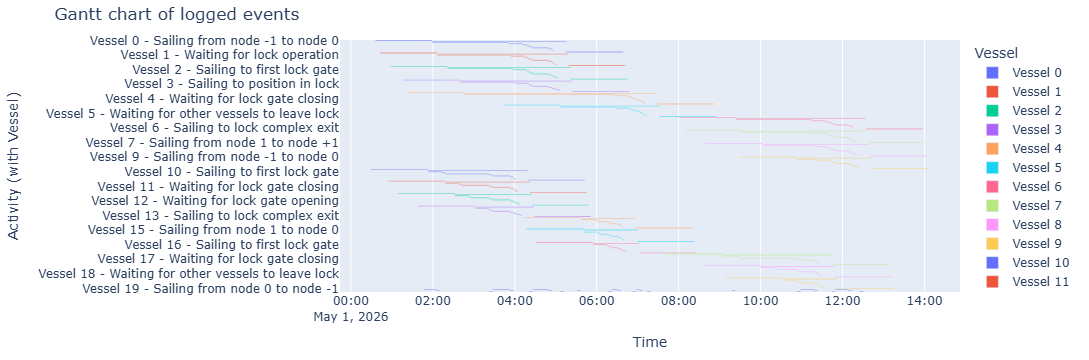

In [14]:
df_eventtable = logbook2eventtable([*vessels, lock_chamber])
fig = generate_vessel_gantt_chart(df_eventtable)

##### Time-distance diagram of vessels passing the lock and planning info
Luckily, the time-distance diagram shows the behaviour of the vessels in a more comprehensible manner. Waiting times emerge.

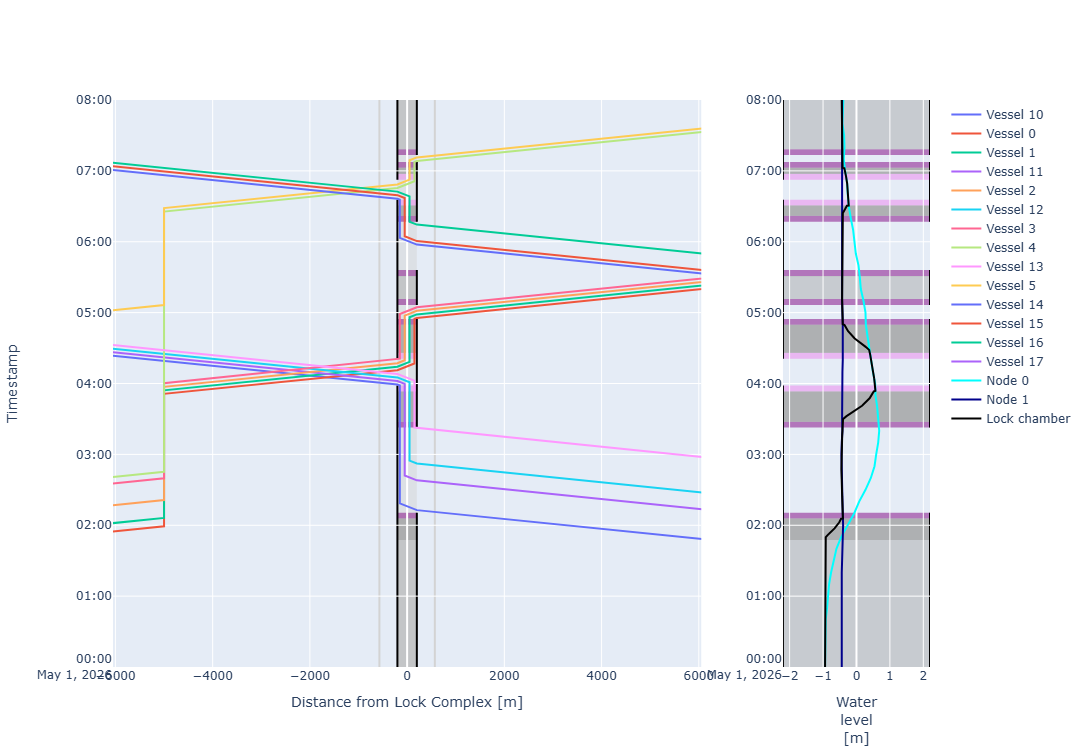

In [15]:
def cm_to_pixels(cm):
    return cm * 37.8 # Set figure height to 10 cmfig.update_layout(height=cm_to_pixels(10))

# We can plot the time-distance diagram
fig = lock_chamber.plot(xlimmin = -6050, 
                        xlimmax = 6050,
                        ylimmin = pd.Timestamp('2026-05-01 00:00:00'),
                        ylimmax = pd.Timestamp('2026-05-01 08:00:00'),
                        method='Plotly',
                        boundary_nodes = ['-1','+1'])

fig.update_layout(height=cm_to_pixels(20))

In [16]:
lock_complex.operation_planning

,node_from,node_to,direction,lock_chamber,operation_index,vessels,capacity_L,capacity_B,time_potential_lock_gate_opening_stop,time_lock_operation_start,...,time_gate_opening_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
1,0,1,0,Lock,0,[],400.0,50.0,2026-05-01 00:29:28.708828,2026-05-01 00:29:28.708828,...,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,2026-05-01 00:56:28.708828,-0.931067,-0.458533,NaN,NaN,NaN
0,1,0,1,Lock,1,[<opentnsim.core.utils.Vessel object at 0x0000...,0.0,50.0,2026-05-01 00:56:28.708828,2026-05-01 00:54:56.208828,...,2026-05-01 03:58:19.415901352,2026-05-01 03:58:19.415901352,2026-05-01 04:08:08.012013704,2026-05-01 04:09:40.512013704,2026-05-01 04:10:08.012013704,0.566683,-0.42765,NaN,NaN,processed
2,0,1,0,Lock,2,[<opentnsim.core.utils.Vessel object at 0x0000...,0.0,50.0,2026-05-01 04:09:40.512013822,2026-05-01 04:09:40.512013822,...,2026-05-01 04:54:41.608126174,2026-05-01 04:54:41.608126174,2026-05-01 05:04:30.204238526,2026-05-01 05:06:02.704238526,2026-05-01 05:06:30.204238526,0.562133,-0.4142,NaT,NaT,processed
4,1,0,1,Lock,3,[<opentnsim.core.utils.Vessel object at 0x0000...,100.0,50.0,2026-05-01 05:56:02.187056,2026-05-01 05:56:02.187056,...,2026-05-01 06:35:37.736681058,2026-05-01 06:35:37.736681058,2026-05-01 06:42:26.332793410,2026-05-01 06:43:58.832793410,2026-05-01 06:44:26.332793410,-0.23185,-0.42,NaT,NaT,processed
3,0,1,0,Lock,4,[<opentnsim.core.utils.Vessel object at 0x0000...,200.0,50.0,2026-05-01 07:41:02.333312,2026-05-01 07:41:02.333312,...,2026-05-01 07:51:12.333312,2026-05-01 07:51:12.333312,2026-05-01 07:51:12.333312,2026-05-01 07:51:12.333312,2026-05-01 07:51:12.333312,-0.413967,-0.4138,NaT,NaT,processed
5,1,0,1,Lock,5,[<opentnsim.core.utils.Vessel object at 0x0000...,100.0,50.0,2026-05-01 08:00:20.360039,2026-05-01 08:00:20.360039,...,2026-05-01 11:24:09.457162058,2026-05-01 11:24:09.457162058,2026-05-01 11:30:58.053274410,2026-05-01 11:32:30.553274410,2026-05-01 11:32:58.053274410,-1.06915,-0.44,NaN,NaN,processed
6,0,1,0,Lock,6,[<opentnsim.core.utils.Vessel object at 0x0000...,0.0,50.0,2026-05-01 11:32:30.553274822,2026-05-01 11:32:30.553274822,...,2026-05-01 12:13:21.649387174,2026-05-01 12:13:21.649387174,2026-05-01 12:23:10.245499526,2026-05-01 12:24:42.745499526,2026-05-01 12:25:10.245499526,-1.0523,-0.46,NaT,NaT,processed


##### Lock performance
We can simply get the performance using the <i>get_performance</i> function of the <strong>lock chamber</strong> object. This function calculates various KPI (key performance indicators):
- <strong>Vessel delay</strong>:
we calculate observed delays of vessels relative to their normal cruising speed at the edge. Delays emerge due to waiting times in the waiting areas and at the lock, levelling times, and sailing in and out of the lock at reduced speeds.
- <strong>Lock occupancy</strong>:
we calculate the lock occupancy by dividing the sum of the lengths of the vessels by the length dimension of the lock chamber.
- <strong>I/C ratio</strong> (traffic load, see Section 3.1 of Lecture Notes):
we calculate the intensity and divide it by the estimated lock capacity, both expressed as the number of vessels that pass the lock per hour. The intensity is calculated by identifying the lock operation cycles, their durations and the number of levelled vessels. The capacity is calculated based on the operation times, including loop times, sailing in times and gaps between vessels, and levelling times (see example box 3.1 of the Lecture Notes).

We start by calculating information for each cycle. We determine each cycle, including how long each lock process took (i.e., start and stop times, directions, loop times, sailing-in times, closing doors, levelling, opening doors, sailing-out times, and how many vessels were levelled).

In [17]:
Tc_df = calculate_cycle_information(lock_chamber)
Tc_df

ValueError: All arrays must be of the same length

This is the information for the second cycle:

In [ ]:
pd.DataFrame(lock_chamber.logbook)

We can also get the aggregated cycle information

In [ ]:
lock_chamber.get_aggregated_cycle_information()

###### <strong>Vessel delay</strong>
We present the results of the vessel delay calculations in the following forms: all the components that contributed to the delay, and aggregated per lock complex area and cause. Delays are defined as such that the vessel speed deviates from its normal cruising speed.

In [ ]:
vessel_delays, vessel_delay_locations, vessel_delays_causes = get_vessel_delays(lock_chamber)
vessel_delays

We observe that most delay takes place in the waiting area.

In [ ]:
vessel_delay_locations

This is because most waiting time is related to congestion. In addition, the lock operation takes significant time and is augmented by additional waiting time for other vessels to sail into/out of the lock chamber. The reduced sailing speed for manoeuvring into/out of the lock contributes to this.

In [ ]:
vessel_delays_causes

###### <strong>Lock occupancy</strong>
We show the results of the calculation of the occupancy of the lock (for each operation, and the average value):

In [ ]:
occupancy, occupancy_df = calculate_lock_occupancy(lock_chamber)
display(occupancy_df)
print(f"The mean occupancy equals {occupancy} %")

###### <strong>I/C ratio</strong>
We show the results of the calculation of the capacity of the lock:

In [ ]:
capacity, cycle_duration, cycle_duration_in_detail = estimate_lock_capacity(lock_chamber)
print(f"The capacity of the lock is {np.round(capacity,2)} vessels/hour \n")
print(f"The cycle duration equals {cycle_duration['Cycle duration']}, caused by:")
display(pd.Series(cycle_duration).drop("Cycle duration"))
print()
print("The following information was used/estimated to determine the capacity:")
display(cycle_duration_in_detail)

We can also determine the intensity <i>I_s</i> for each half lock operation cycle

In [ ]:
display(Tc_df[['Start time of cycle', 'Stop time of cycle', 'Direction first operation', 'Direction second operation', 
               'Number of upstream vessels', 'Number of downstream vessels', 'Intensity (I_s)']])
print(f"This results in an cycle-average intensity of: {np.round(Tc_df['Intensity (I_s)'].mean(),2)} vessels/hour")

###### <strong>Aggregated lock performance</strong>
The observed KPIs show that there is some significant delay, as the I/C-ratio is high (0.63). The cycle times are significant, particularly due to the duration of sailing in of vessels (29.46%), gate movements (21.48%) and levelling (21.48%).

In [ ]:
summary = lock_chamber.get_performance()

In [ ]:
lock_chamber.lock_complex.operation_planning

In [ ]:
lock_complex.operation_planning

In [ ]:
gate_A_df = pd.DataFrame(lock_chamber.gate_A.logbook)
gate_A_df